# MODEL SELECTION

## Objetive

- Establish baseline performance.
- Compare multiple classification models.
- Select the best model using cross-validation.
- Evaluate the final model on the test set.

## Imports y Configuración

In [50]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

RANDOM_STATE = 18
N_SPLITS = 5

ARTIFACTS_DIR = Path("../artifacts")

CV = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

SCORING = {
    "accuracy": "accuracy",
    "f1": "f1_weighted",  # IMPORTANTE (multiclase)
    "roc_auc": "roc_auc_ovr"  # IMPORTANTE (multiclase)
}

## Carga datos y Pipeline

In [51]:
## Carga datos y Pipeline
full_pipeline = joblib.load(ARTIFACTS_DIR / "preprocess_pipeline.joblib")
preprocess_pipeline = full_pipeline.named_steps["preprocessor"]

X_train, X_test, y_train, y_test = joblib.load(
    ARTIFACTS_DIR / "split_data.joblib"
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (80, 25)
Test shape: (20, 25)


In [52]:
print("Columnas en X_train:")
print(X_train.columns.tolist())
print("\n¿Existe 'number_of_times_character_spoke'?", 'number_of_times_character_spoke' in X_train.columns)

Columnas en X_train:
['Gender', 'Species', 'Blood status', 'number_of_times_character_spoke', 'mentioned_charm', 'mentioned_conjuration', 'mentioned_spell', 'mentioned_healing spell', 'mentioned_vanishment', 'mentioned_hex', 'mentioned_jinx', 'mentioned_curse', 'mentioned_transportation', 'mentioned_transfiguration', 'mentioned_transformation', 'mentioned_dark charm', 'mentioned_counter-charm', 'mentioned_transfiguration\xa0jinx', 'mentioned_transfiguration\xa0spell', 'mentioned_counter-spell', 'mentioned_dark arts', 'mentioned_counter-jinx', 'mentioned_patented\xa0charm', 'mentioned_counter-curse', 'mentioned_untransfiguration']

¿Existe 'number_of_times_character_spoke'? True


Helper

In [53]:
def make_model_pipeline(preprocess_pipeline, model):
    return Pipeline([
        ("preprocess", preprocess_pipeline),
        ("model", model)
    ])

## Modelos

In [54]:
baseline_models = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

candidate_models = {
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
}

## Funcion de Evaluacion (CV)

In [55]:
def evaluate_model_cv(model_name, preprocess_pipeline, model, X_train, y_train):
    model_pipeline = make_model_pipeline(preprocess_pipeline, model)

    cv_results = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=CV,
        scoring=SCORING,
        n_jobs=-1
    )

    return {
        "model": model_name,
        "cv_accuracy_mean": np.mean(cv_results["test_accuracy"]),
        "cv_f1_mean": np.mean(cv_results["test_f1"]),
        "cv_roc_auc_mean": np.mean(cv_results["test_roc_auc"]),
    }

## Baselines

In [56]:
baseline_results = []

for name, model in baseline_models.items():
    baseline_results.append(
        evaluate_model_cv(name, preprocess_pipeline, model, X_train, y_train)
    )

baseline_df = pd.DataFrame(baseline_results).sort_values(
    by="cv_f1_mean", ascending=False
)

baseline_df

,model,cv_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
2,decision_tree,0.4375,0.386135,NaN
1,logistic_regression,0.3625,0.329926,NaN
0,dummy,0.3750,0.204545,NaN


## Candidatos

In [57]:
candidate_results = []

for name, model in candidate_models.items():
    candidate_results.append(
        evaluate_model_cv(name, preprocess_pipeline, model, X_train, y_train)
    )

candidate_df = pd.DataFrame(candidate_results).sort_values(
    by="cv_f1_mean", ascending=False
)

candidate_df

,model,cv_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
0,random_forest,0.4375,0.382244,NaN
1,hist_gradient_boosting,0.3875,0.353716,NaN


## Comparación total

In [58]:
all_results = pd.concat([baseline_df, candidate_df]).sort_values(
    by="cv_f1_mean", ascending=False
).reset_index(drop=True)

all_results

,model,cv_accuracy_mean,cv_f1_mean,cv_roc_auc_mean
0,decision_tree,0.4375,0.386135,NaN
1,random_forest,0.4375,0.382244,NaN
2,hist_gradient_boosting,0.3875,0.353716,NaN
3,logistic_regression,0.3625,0.329926,NaN
4,dummy,0.3750,0.204545,NaN


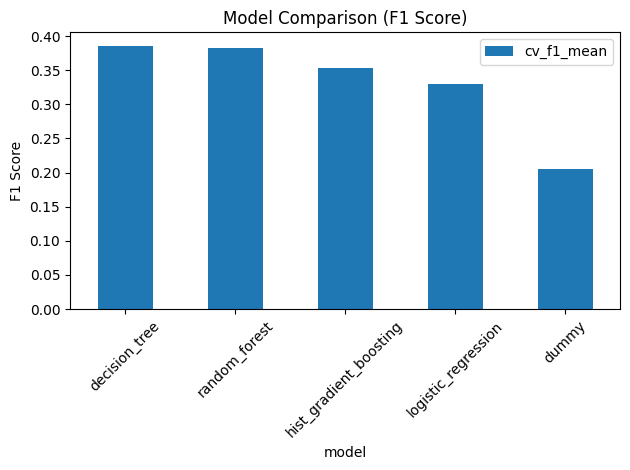

In [59]:
import matplotlib.pyplot as plt

all_results.plot(x="model", y="cv_f1_mean", kind="bar")
plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Selección del mejor modelo

In [60]:
best_model_name = all_results.iloc[0]["model"]
best_model_name

'decision_tree'

## Entrenamiento final

In [61]:
if best_model_name == "dummy":
    final_model = DummyClassifier(strategy="most_frequent")

elif best_model_name == "logistic_regression":
    final_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

elif best_model_name == "decision_tree":
    final_model = DecisionTreeClassifier(random_state=RANDOM_STATE)

elif best_model_name == "random_forest":
    final_model = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

elif best_model_name == "hist_gradient_boosting":
    final_model = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

final_pipeline = make_model_pipeline(preprocess_pipeline, final_model)

final_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

## Test (Evaluacion Final)

In [62]:
y_pred = final_pipeline.predict(X_test)

# ROC-AUC multiclase
y_proba = final_pipeline.predict_proba(X_test)

results = {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred, average="weighted"),
    "roc_auc": roc_auc_score(y_test, y_proba, multi_class="ovr")
}

pd.DataFrame([results])

,accuracy,f1,roc_auc
0,0.4,0.33647,0.565646


## Reporte

In [63]:
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

                              precision    recall  f1-score   support

Beauxbatons Academy of Magic       0.00      0.00      0.00         1
                  Gryffindor       0.40      0.25      0.31         8
                  Hufflepuff       0.00      0.00      0.00         2
                   Ravenclaw       0.33      0.25      0.29         4
                   Slytherin       0.45      1.00      0.62         5

                    accuracy                           0.40        20
                   macro avg       0.24      0.30      0.24        20
                weighted avg       0.34      0.40      0.34        20

Confusion Matrix:
[[0 0 0 1 0]
 [0 2 1 1 4]
 [0 1 0 0 1]
 [0 2 0 1 1]
 [0 0 0 0 5]]


# Final Model Selection

The selected model is: **'decision_tree'**

## Justification

- It achieved the highest cross-validated F1-score.
- It maintained strong performance across Accuracy and ROC-AUC.
- It generalizes better compared to simpler models like Logistic Regression or Decision Tree.
- Ensemble models (if selected) capture complex patterns in the data such as spell usage and dialogue frequency.

## Conclusion

The selected model provides the best balance between performance and robustness for predicting a character's House.